# Árboles - Random Search
El objetivo de este notebook es ejectutar una serie de random search en distintos modelos de árboles

Los resultados se guardan en .csv en la carpeta /results/random_search.csv. El análisis de los resultados se hace en 08-arboles-analisis.ipynb

In [9]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import sys


sys.path.append('..')

from sklearn import set_config
set_config(transform_output="pandas")
from scipy.stats import randint, uniform
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from src.constants import COLS, DEV_SET_CLEAN_PATH, DEV_SET_CLEAN_NORMAL_PATH, DEV_SET_CLEAN_OUTLIERS_PATH
from src.config import TREE_BASED_CONFIG_NORMAL, TREE_BASED_CONFIG_OUTLIERS
from src.pipeline import build_feature_pipeline, build_target_pipeline
from src.plots import plot_cv_results, plot_grid_search_results
from src.model_evaluation import evaluate_models_cv, grid_search_cv

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


En este notebook vamos a hacer una busqueda de hiperparámetros y comparar la performance de modelos de XGBoost, LightGBM y Random Forest

# 1. Dataset Normal

In [10]:
OVERFITTING_CUTOFF = 70

df_normal = pd.read_csv("../" + DEV_SET_CLEAN_NORMAL_PATH)
X_normal = df_normal.drop(columns=[COLS.TARGET])
y_normal = df_normal[COLS.TARGET]

In [11]:
# construimos pipelines
feature_pipeline_normal = build_feature_pipeline(TREE_BASED_CONFIG_NORMAL)
target_pipeline_normal = build_target_pipeline(TREE_BASED_CONFIG_NORMAL)

## 1.1 Modelos base
Entrenamos modelos baseline con hiperparámetros predeterminados para tener un baseline para comparar


In [12]:
base_models = {
    'XBoost': XGBRegressor(
        random_state=42,
        n_jobs=-1
    ),
    'LightGBM': LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    # 'RandomForest': RandomForestRegressor(
    #     random_state=42,
    #     max_depth=10, # solo limitamos max_depth para que no tarde una eternidad
    #     n_jobs=-1
    # )
}

In [13]:
base_normal_results = evaluate_models_cv(
    base_models,
    X_normal,
    y_normal,
    feature_pipeline_normal,
    target_pipeline_normal
)


🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando XBoost...
  ✓ MAE: 4,991 ± 46
  ✓ RMSE: 11,595 ± 369

Entrenando LightGBM...
  ✓ MAE: 5,887 ± 77
  ✓ RMSE: 14,084 ± 355



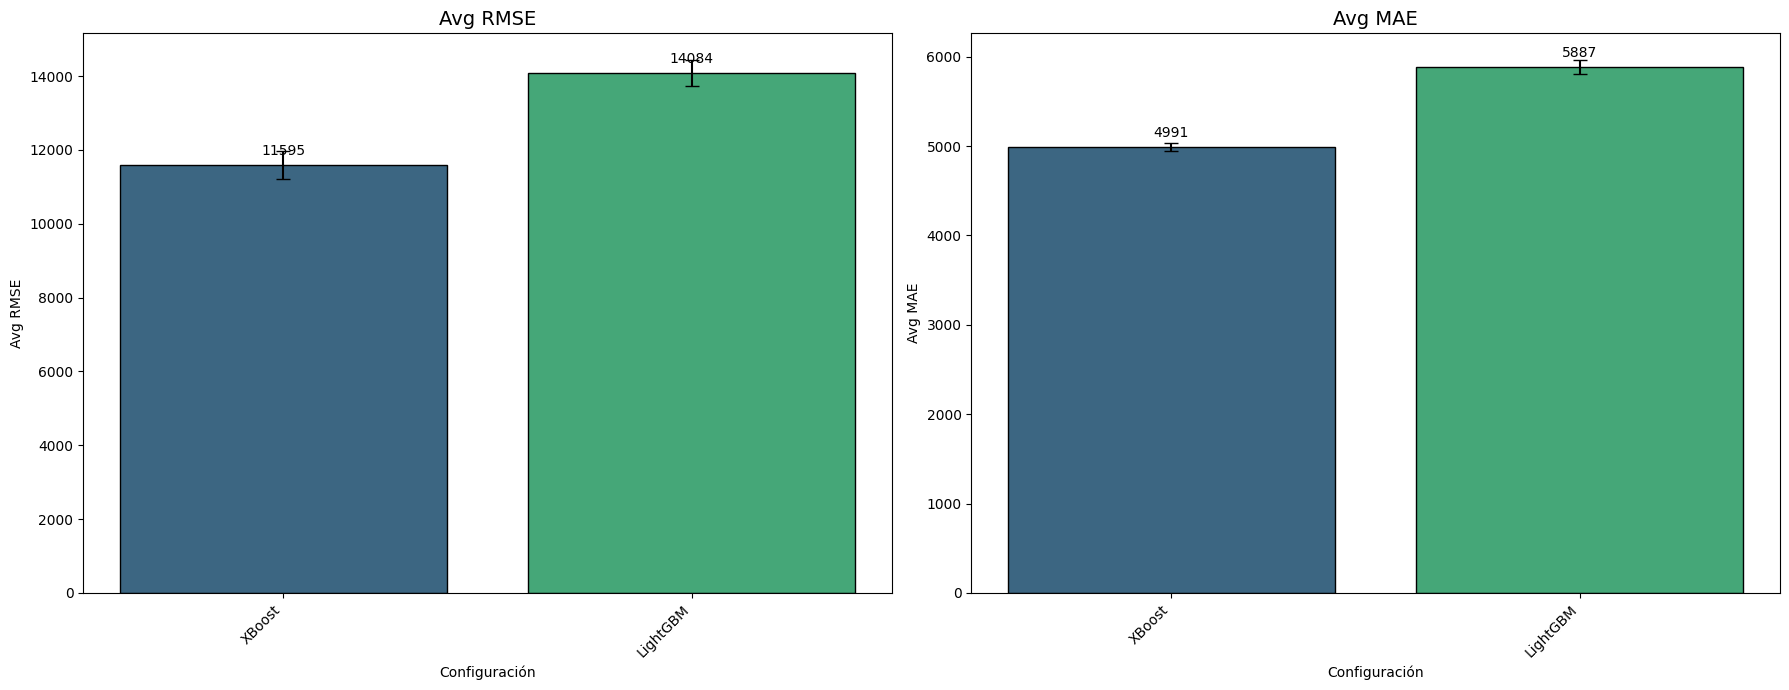

In [14]:
plot_cv_results(base_normal_results, vertical_layout=False)

## 1.2 Grid Search - XGBoost

In [15]:
xgb_random_search_params = {
    'max_depth': randint(6, 15),
    'learning_rate': uniform(0.01, 0.3),
    'n_estimators': [300, 500, 600, 800, 900, 1000],
    'min_child_weight': randint(1, 20),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0.0, 0.5),
    'reg_lambda': uniform(0.0, 5.0)
}

In [16]:
xgb_grid_results = grid_search_cv(
    model_class=XGBRegressor,
    param_grid=xgb_random_search_params,
    X=X_normal,
    y=y_normal,
    feature_pipeline=feature_pipeline_normal,
    target_pipeline=target_pipeline_normal,
    n_splits=3,
    n_iter=500,
    verbose=True
)


🔍 RandomizedSearchCV: 500 combinaciones × 3 folds = 1500 fits
   Modelo: XGBRegressor



Optimizando:   0%|          | 0/1500 [00:00<?, ?it/s]


✅ Mejor MAE: 2,536
   Mejores params: {'regressor__model__colsample_bytree': np.float64(0.7815158165534557), 'regressor__model__gamma': np.float64(0.11802523167323198), 'regressor__model__learning_rate': np.float64(0.032049024199003795), 'regressor__model__max_depth': 14, 'regressor__model__min_child_weight': 1, 'regressor__model__n_estimators': 900, 'regressor__model__reg_lambda': np.float64(1.2435713629381495), 'regressor__model__subsample': np.float64(0.846857994641612)}
   Overfitting gap: 257.2% ❌ (overfitting!)


In [17]:
xgb_grid_results.to_csv("../results/random_search/xgb_normal.csv")

def get_best_not_overfitted(results):
    results_out = results.copy()
    return results_out[results_out['overfit_gap_%'] < OVERFITTING_CUTOFF].sort_values('rmse_mean')

xgb_grid_results_cut = get_best_not_overfitted(xgb_grid_results)
xgb_grid_results_cut.head()

,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
217,0.620936,0.189238,0.118883,8,2,1000,1.667848,0.832190,3042.252432,9.549986,7780.898497,177.319067,1850.168757,21.733026,3522.280615,58.483560,64.431078
158,0.720385,0.354086,0.030205,11,1,1000,3.104578,0.618297,2955.540467,13.301020,7796.326827,192.112101,1754.302270,16.822273,3476.232678,47.068079,68.473844
327,0.715698,0.450042,0.044842,10,3,1000,3.014714,0.930683,2972.268495,17.378191,7815.830229,196.604915,1775.821871,15.912359,3588.295068,41.211364,67.374248
34,0.878412,0.285031,0.039153,11,2,600,1.476453,0.729020,3008.110953,18.294395,7913.643987,145.094972,1782.242551,14.559312,3458.774643,40.235094,68.782355
258,0.800820,0.062357,0.125613,9,10,1000,2.965222,0.756610,3109.614893,8.390005,7915.763321,151.579319,1854.714190,40.766908,3716.882956,111.618723,67.660058


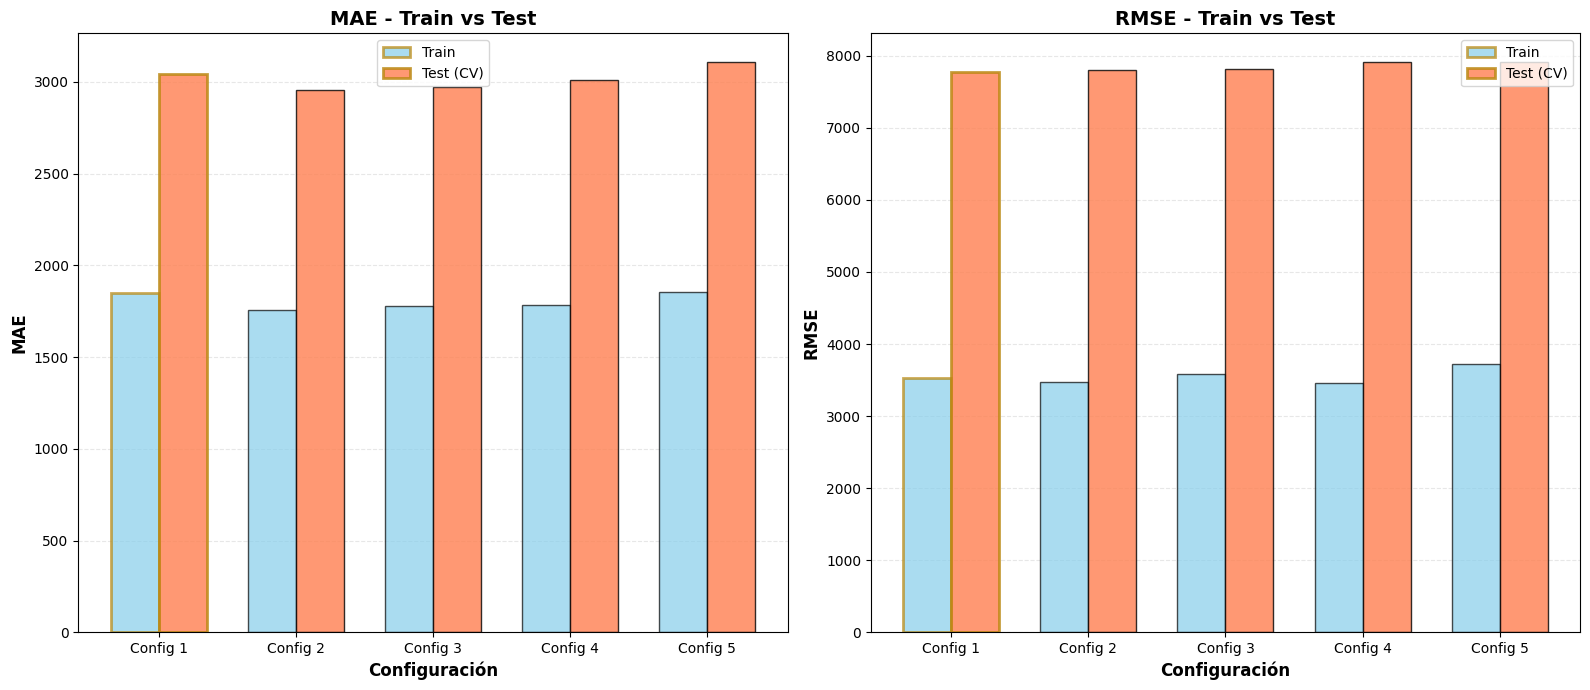


📋 Parámetros de cada configuración:
          colsample_bytree     gamma  learning_rate  max_depth  min_child_weight  n_estimators  reg_lambda  subsample     mae_mean  train_mae_mean  overfit_gap_%
Config 1          0.620936  0.189238       0.118883          8                 2          1000    1.667848   0.832190  3042.252432     1850.168757      64.431078
Config 2          0.720385  0.354086       0.030205         11                 1          1000    3.104578   0.618297  2955.540467     1754.302270      68.473844
Config 3          0.715698  0.450042       0.044842         10                 3          1000    3.014714   0.930683  2972.268495     1775.821871      67.374248
Config 4          0.878412  0.285031       0.039153         11                 2           600    1.476453   0.729020  3008.110953     1782.242551      68.782355
Config 5          0.800820  0.062357       0.125613          9                10          1000    2.965222   0.756610  3109.614893     1854.714190      6

In [18]:
plot_grid_search_results(xgb_grid_results_cut, top_n=5, overfitting_cutoff=OVERFITTING_CUTOFF)

## 1.3 Grid Search - LightGBM

In [19]:
lgbm_param_grid = {
    # Complejidad del árbol (equivalente a max_depth)
    'num_leaves': randint(10, 50),        # [10, 49] - Conservador para evitar overfitting

    # Learning rate y número de árboles
    'learning_rate': uniform(0.01, 0.29),
    'n_estimators': [300, 500, 800, 1000, 1200],

    # Regularización (prevenir overfitting)
    'min_child_samples': randint(10, 50), # [10, 49] - Mínimo de muestras por hoja
    'min_child_weight': uniform(0, 20), # [0.001, 0.1] - Peso mínimo

    # Subsampling (añade randomness)
    'subsample': uniform(0.6, 0.4),       # [0.6, 1.0]
    'colsample_bytree': uniform(0.6, 0.4),# [0.6, 1.0]

    # Regularización L1/L2
    'reg_alpha': uniform(0, 5.0),         # [0, 2.0] - L1
    'reg_lambda': uniform(0, 5.0),        # [0, 2.0] - L2
}

In [20]:
lgbm_grid_results = grid_search_cv(
    model_class=LGBMRegressor,
    param_grid=lgbm_param_grid,
    X=X_normal,
    y=y_normal,
    feature_pipeline=feature_pipeline_normal,
    target_pipeline=target_pipeline_normal,
    n_splits=3,
    verbose=True,
    n_iter=500,
)


🔍 RandomizedSearchCV: 500 combinaciones × 3 folds = 1500 fits
   Modelo: LGBMRegressor



Optimizando:   0%|          | 0/1500 [00:00<?, ?it/s]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.073558 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2355
[LightGBM] [Info] Number of data points in the train set: 177776, number of used features: 39
[LightGBM] [Info] Start training from score 24105.686564
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.102862 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2350
[LightGBM] [Info] Number of data points in the train set: 177776, number of used features: 39
[LightGBM] [Info] Start training from score 23931.096741
[LightGBM] [Warnin

In [21]:
lgbm_grid_results.to_csv("../results/random_search/lgbm_normal.csv")

lgbm_grid_results_cut = get_best_not_overfitted(lgbm_grid_results)
lgbm_grid_results_cut.head()

,colsample_bytree,learning_rate,min_child_samples,min_child_weight,n_estimators,num_leaves,reg_alpha,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
206,0.893446,0.233098,11,2.676075,1200,47,1.299066,3.801449,0.654844,3266.959748,12.630446,8115.816722,203.115698,2133.004746,12.157612,4204.854013,6.318926,53.162329
210,0.863477,0.283421,11,8.752062,1200,42,4.204358,0.192132,0.960705,3282.879378,15.609106,8149.226178,162.198427,2035.827903,10.838071,3894.974387,16.961308,61.255250
318,0.929324,0.236784,19,0.293868,1200,47,1.686728,0.096638,0.649747,3339.924916,13.888936,8222.666756,175.192574,2171.970417,14.300276,4354.730312,48.403119,53.773960
354,0.813716,0.166813,10,6.176688,1200,44,4.762336,1.133637,0.951736,3378.145397,22.035640,8286.718136,211.231516,2395.435511,7.742575,4820.745022,26.945398,41.024268
9,0.965984,0.256511,21,6.617960,1200,44,2.956489,1.373609,0.824497,3380.432346,6.452457,8315.887622,188.398544,2224.127466,15.459724,4471.706904,58.513340,51.989146


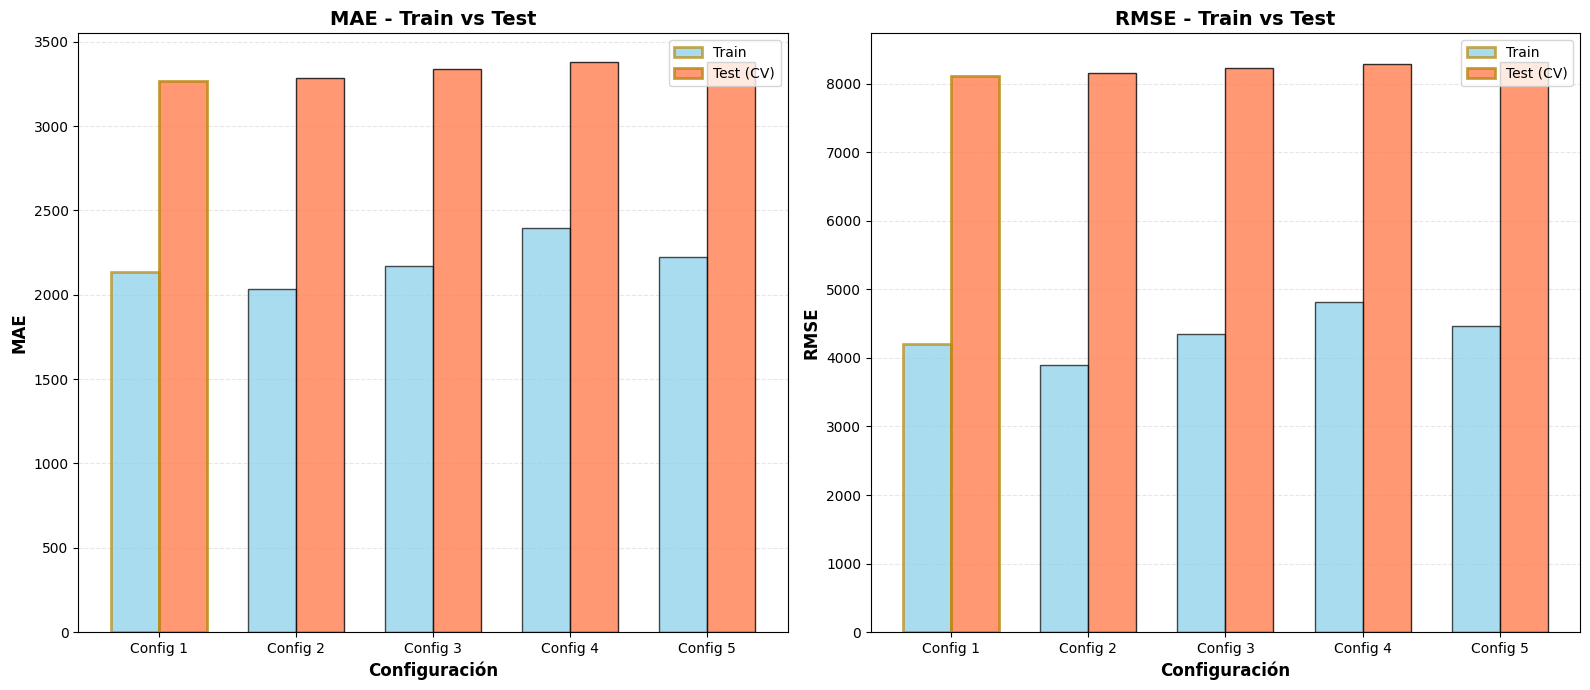


📋 Parámetros de cada configuración:
          colsample_bytree  learning_rate  min_child_samples  min_child_weight  n_estimators  num_leaves  reg_alpha  reg_lambda  subsample     mae_mean  train_mae_mean  overfit_gap_%
Config 1          0.893446       0.233098                 11          2.676075          1200          47   1.299066    3.801449   0.654844  3266.959748     2133.004746      53.162329
Config 2          0.863477       0.283421                 11          8.752062          1200          42   4.204358    0.192132   0.960705  3282.879378     2035.827903      61.255250
Config 3          0.929324       0.236784                 19          0.293868          1200          47   1.686728    0.096638   0.649747  3339.924916     2171.970417      53.773960
Config 4          0.813716       0.166813                 10          6.176688          1200          44   4.762336    1.133637   0.951736  3378.145397     2395.435511      41.024268
Config 5          0.965984       0.256511       

In [22]:
plot_grid_search_results(lgbm_grid_results_cut, top_n=5, overfitting_cutoff=OVERFITTING_CUTOFF)

# 2. Dataset Outliers

In [23]:
df_outliers = pd.read_csv("../" + DEV_SET_CLEAN_OUTLIERS_PATH)
X_outliers = df_outliers.drop(columns=[COLS.TARGET])
y_outliers = df_outliers[COLS.TARGET]

In [24]:
# construimos pipelines
feature_pipeline_outliers = build_feature_pipeline(TREE_BASED_CONFIG_OUTLIERS)
target_pipeline_outliers = build_target_pipeline(TREE_BASED_CONFIG_OUTLIERS)

## 2.1 Modelos base

In [25]:
base_outliers_results = evaluate_models_cv(
    base_models,
    X_outliers,
    y_outliers,
    feature_pipeline_outliers,
    target_pipeline_outliers
)


🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando XBoost...
  ✓ MAE: 458,953 ± 24,058
  ✓ RMSE: 1,140,202 ± 162,189

Entrenando LightGBM...
  ✓ MAE: 583,349 ± 38,693
  ✓ RMSE: 1,286,722 ± 193,552



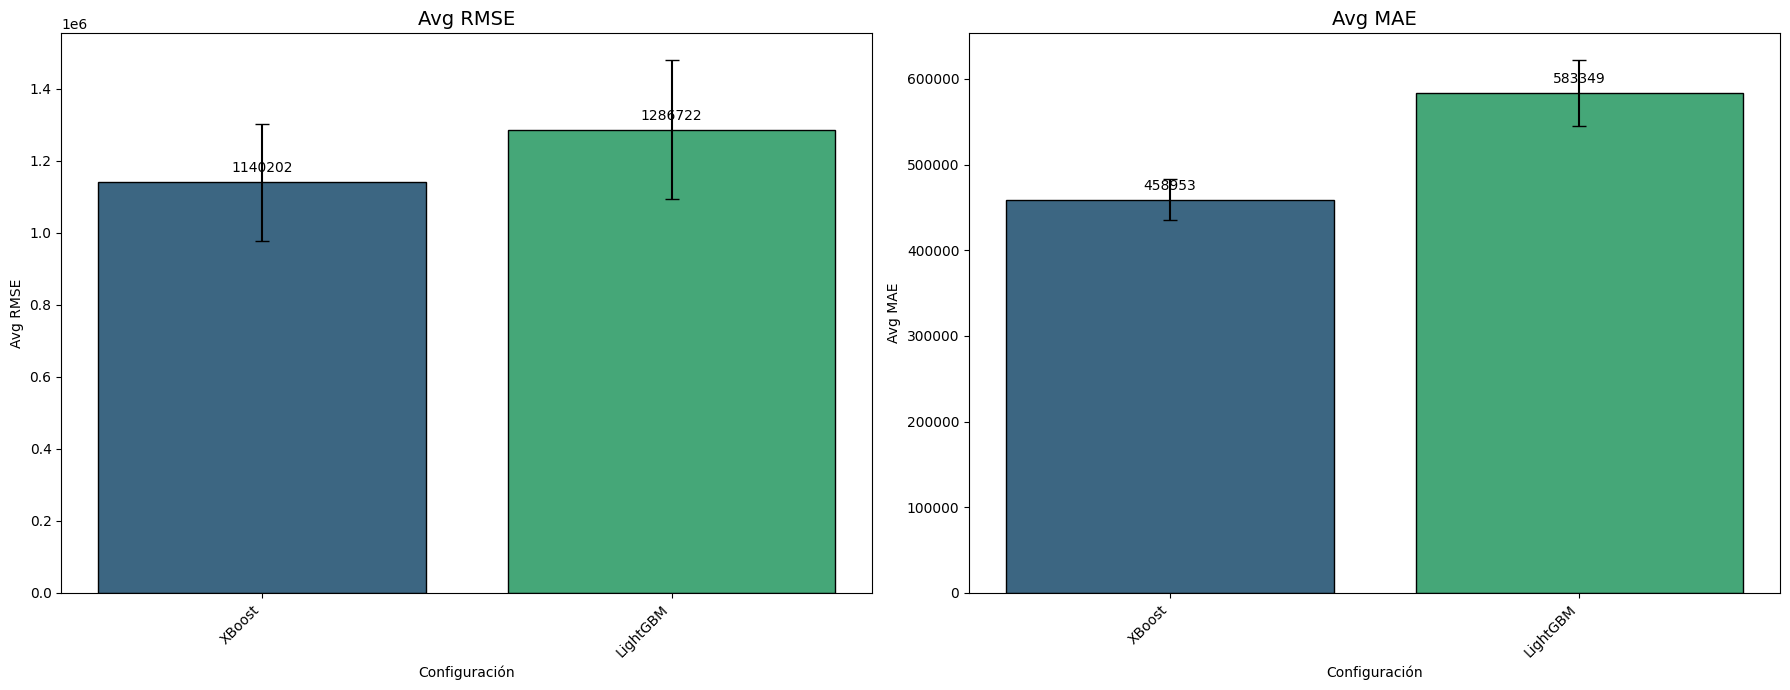

In [26]:
plot_cv_results(base_outliers_results, vertical_layout=False)

## 2.2 Grid Search - XGBoost
En este dataset las muestras son muy pocas -- vamos a ser más cuidadosos con el overfitting

In [27]:
xgb_random_search_params_outliers = {
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.005, 0.045),
    'n_estimators': [500, 700, 1000, 1500], # Más árboles simples

    # Regularización fuerte
    'min_child_weight': randint(5, 30),
    'min_child_samples': randint(3, 15),
    'gamma': uniform(0.1, 0.9),           # [0.1, 1.0] vs [0.0, 0.5]
    'reg_alpha': uniform(0.5, 2.5),       # [0.5, 3.0] - L1 regularization
    'reg_lambda': uniform(1.0, 4.0),      # [1.0, 5.0] vs [0.0, 5.0] - L2 ALTO

    # Subsampling MÁS AGRESIVO (más randomness)
    'subsample': uniform(0.5, 0.4),       # [0.5, 0.9] vs [0.6, 1.0]
    'colsample_bytree': uniform(0.5, 0.4),# [0.5, 0.9] vs [0.6, 1.0]
    'subsample_freq': [1],                # Hacer subsample en cada iteración

}

In [28]:
xgb_outliers_results = grid_search_cv(
    model_class=XGBRegressor,
    param_grid=xgb_random_search_params,
    X=X_outliers,
    y=y_outliers,
    feature_pipeline=feature_pipeline_outliers,
    target_pipeline=target_pipeline_outliers,
    n_splits=5,
    n_iter=1000,
    verbose=True
)


🔍 RandomizedSearchCV: 1000 combinaciones × 5 folds = 5000 fits
   Modelo: XGBRegressor



Optimizando:   0%|          | 0/5000 [00:00<?, ?it/s]


✅ Mejor MAE: 392,505
   Mejores params: {'regressor__model__colsample_bytree': np.float64(0.8134217734214317), 'regressor__model__gamma': np.float64(0.00012050234256727466), 'regressor__model__learning_rate': np.float64(0.08237330081140835), 'regressor__model__max_depth': 9, 'regressor__model__min_child_weight': 5, 'regressor__model__n_estimators': 600, 'regressor__model__reg_lambda': np.float64(0.07749120913095153), 'regressor__model__subsample': np.float64(0.6667057075490768)}
   Overfitting gap: 821.5% ❌ (overfitting!)


In [29]:
xgb_outliers_results.to_csv("../results/random_search/xgb_outliers.csv")
xgb_outliers_results_cut = get_best_not_overfitted(xgb_outliers_results)
xgb_outliers_results_cut.head()

,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
748,0.959765,0.066767,0.126009,7,15,500,2.534998,0.828869,538348.857691,33742.192686,1.186834e+06,226087.365352,319636.675266,5948.935270,660424.003979,12024.707155,68.425246
528,0.999049,0.095566,0.147895,7,17,600,4.692649,0.672473,550776.597089,36095.826570,1.186968e+06,198787.170948,337438.122609,6198.515202,689429.300426,24269.030496,63.222991
898,0.728227,0.067489,0.098853,7,1,600,1.733594,0.898581,553657.104586,37179.469430,1.203211e+06,220094.684349,329572.302183,6102.598684,628681.758437,16153.866373,67.992608
703,0.653338,0.121272,0.097508,9,5,500,2.371543,0.667208,560200.574951,33154.589733,1.211835e+06,220706.387904,354682.114377,6966.479309,741312.928562,25722.070416,57.944411
273,0.890062,0.095595,0.111479,8,12,300,0.915077,0.608814,545504.751208,34561.099578,1.217457e+06,197386.120109,331828.094464,6901.009964,680547.244024,20702.881021,64.393781


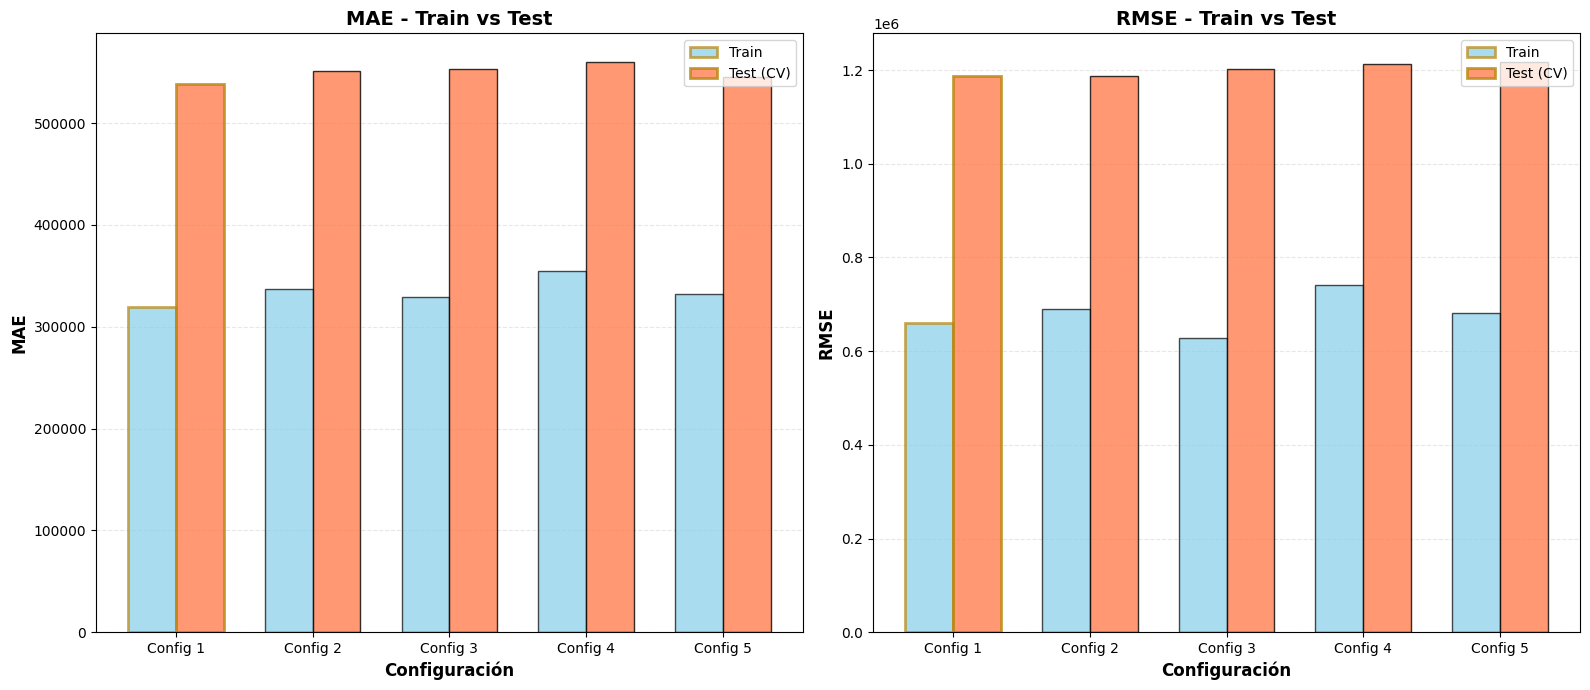


📋 Parámetros de cada configuración:
          colsample_bytree     gamma  learning_rate  max_depth  min_child_weight  n_estimators  reg_lambda  subsample       mae_mean  train_mae_mean  overfit_gap_%
Config 1          0.959765  0.066767       0.126009          7                15           500    2.534998   0.828869  538348.857691   319636.675266      68.425246
Config 2          0.999049  0.095566       0.147895          7                17           600    4.692649   0.672473  550776.597089   337438.122609      63.222991
Config 3          0.728227  0.067489       0.098853          7                 1           600    1.733594   0.898581  553657.104586   329572.302183      67.992608
Config 4          0.653338  0.121272       0.097508          9                 5           500    2.371543   0.667208  560200.574951   354682.114377      57.944411
Config 5          0.890062  0.095595       0.111479          8                12           300    0.915077   0.608814  545504.751208   331828.0

In [30]:
plot_grid_search_results(xgb_outliers_results_cut, top_n=5, overfitting_cutoff=OVERFITTING_CUTOFF)

## 2.3 Grid Search - LightGBM

In [31]:
lgbm_params_outliers = {
    # Árboles MUY SIMPLES
    'num_leaves': randint(5, 20),         # [5, 19] vs [20, 79]

    # Learning rate BAJÍSIMO + más árboles
    'learning_rate': uniform(0.003, 0.047), # [0.003, 0.05] vs [0.01, 0.30]
    'n_estimators': [500, 700, 1000, 1500, 2000],

    # Regularización FUERTE (muchos samples por nodo)
    'min_child_samples': randint(5, 20),  # [5, 19] - Alto para dataset chico
    'min_data_in_leaf': randint(5, 20),   # [5, 19]
    'min_child_weight': uniform(0.01, 0.49), # [0.01, 0.5] vs [0.001, 0.1]

    # Subsampling AGRESIVO
    'subsample': uniform(0.5, 0.4),       # [0.5, 0.9] vs [0.6, 1.0]
    'colsample_bytree': uniform(0.5, 0.4),# [0.5, 0.9] vs [0.6, 1.0]
    'subsample_freq': [1],                # Siempre hacer bagging

    # Penalizaciones FUERTES
    'reg_alpha': uniform(0.5, 3.5),       # [0.5, 4.0] vs [0.0, 2.0] - L1
    'reg_lambda': uniform(1.0, 4.0),      # [1.0, 5.0] vs [0.0, 3.0] - L2

    # PATH_SMOOTH (específico de LightGBM - previene overfitting)
    'path_smooth': uniform(0.5, 1.5),     # [0.5, 2.0] - Suaviza predicciones
}


In [32]:
lgbm_outliers_results = grid_search_cv(
    model_class=LGBMRegressor,
    param_grid=lgbm_params_outliers,
    X=X_outliers,
    y=y_outliers,
    feature_pipeline=feature_pipeline_outliers,
    target_pipeline=target_pipeline_outliers,
    n_splits=5,
    verbose=True,
    n_iter=1000,
)


🔍 RandomizedSearchCV: 1000 combinaciones × 5 folds = 5000 fits
   Modelo: LGBMRegressor



Optimizando:   0%|          | 0/5000 [00:00<?, ?it/s]

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=12 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=12 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007484 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1588
[LightGBM] [Info] Number of data points in the train set: 3246, number of used features: 38
[LightGBM] [Info] Start training from score 14.915461
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=12 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=12 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_d

In [33]:
lgbm_outliers_results.to_csv("../results/random_search/lgbm_outliers.csv")
lgbm_outliers_results_cut = get_best_not_overfitted(lgbm_outliers_results)
lgbm_outliers_results_cut.head()

,colsample_bytree,learning_rate,min_child_samples,min_child_weight,min_data_in_leaf,n_estimators,num_leaves,path_smooth,reg_alpha,reg_lambda,...,subsample_freq,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
714,0.730028,0.039969,12,0.053953,5,700,18,1.211153,0.514372,1.044053,...,1,524873.664676,32771.983658,1.175064e+06,196105.260150,309094.264352,3697.853198,633227.449155,13438.314946,69.810225
44,0.536682,0.031315,8,0.339534,8,2000,11,1.671944,0.897126,4.723716,...,1,530830.669496,35354.586630,1.203875e+06,217752.906111,322660.768388,5983.644573,680929.467583,14566.631182,64.516645
263,0.863782,0.036941,17,0.234649,10,2000,10,1.685765,0.936873,4.176843,...,1,534662.738558,36313.019843,1.205828e+06,187762.529356,315942.053107,4855.412639,666024.783845,20663.510468,69.228102
414,0.837685,0.025749,13,0.161149,8,1000,19,0.907998,0.522327,4.913419,...,1,536818.989262,35923.837474,1.206414e+06,219757.379178,324033.832995,8540.270277,686279.777182,17564.294377,65.667574
827,0.615318,0.033007,19,0.472928,18,1000,18,1.886328,0.585368,3.325700,...,1,538874.511241,36433.831536,1.208309e+06,202814.839804,324825.893049,7556.135033,697559.334302,19981.043001,65.896415


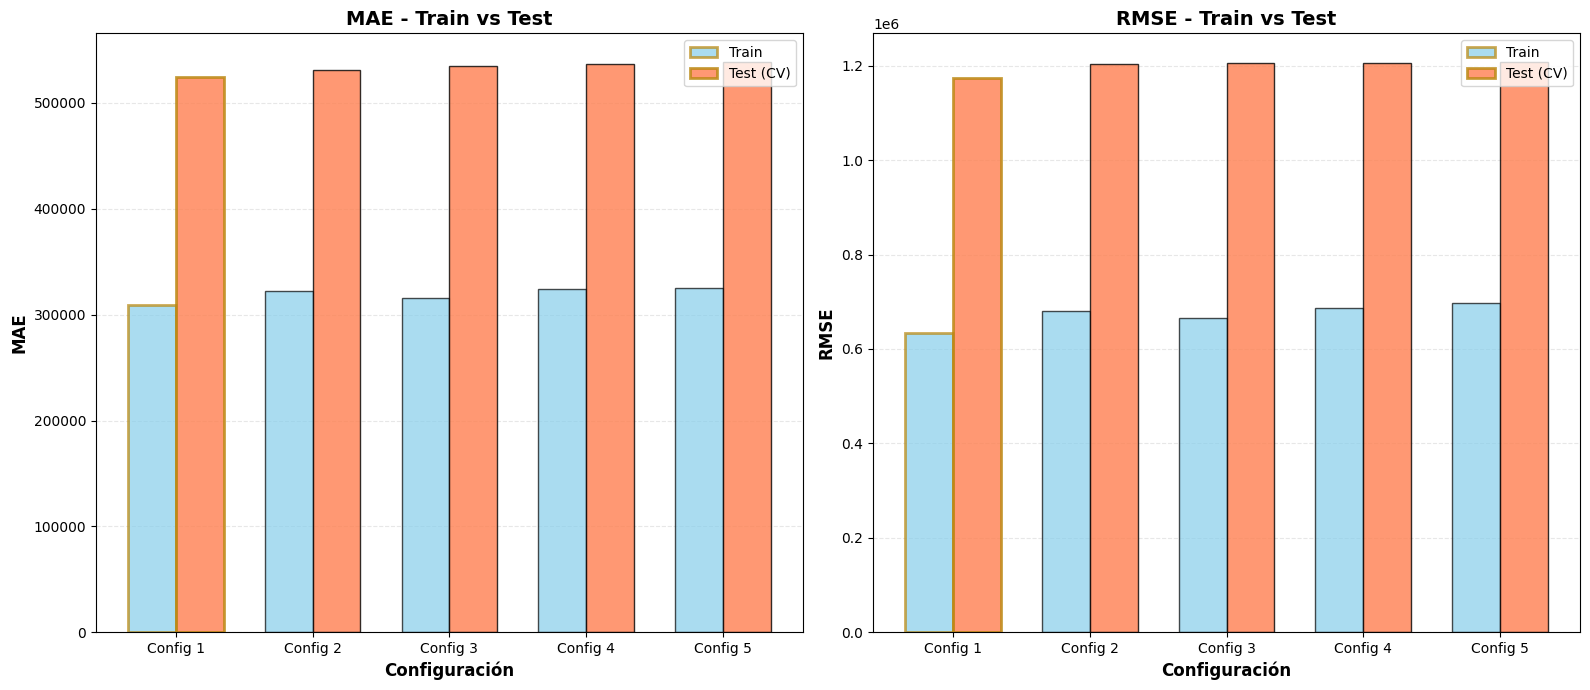


📋 Parámetros de cada configuración:
          colsample_bytree  learning_rate  min_child_samples  min_child_weight  min_data_in_leaf  n_estimators  num_leaves  path_smooth  reg_alpha  reg_lambda  subsample  subsample_freq       mae_mean  train_mae_mean  overfit_gap_%
Config 1          0.730028       0.039969                 12          0.053953                 5           700          18     1.211153   0.514372    1.044053   0.666654               1  524873.664676   309094.264352      69.810225
Config 2          0.536682       0.031315                  8          0.339534                 8          2000          11     1.671944   0.897126    4.723716   0.889699               1  530830.669496   322660.768388      64.516645
Config 3          0.863782       0.036941                 17          0.234649                10          2000          10     1.685765   0.936873    4.176843   0.610307               1  534662.738558   315942.053107      69.228102
Config 4          0.837685       0.

In [34]:
plot_grid_search_results(lgbm_outliers_results_cut, top_n=5, overfitting_cutoff=OVERFITTING_CUTOFF)

# 3. Dataset completo

In [35]:
df_full = pd.read_csv("../" + DEV_SET_CLEAN_PATH)
X_full = df_full.drop(columns=[COLS.TARGET])
y_full = df_full[COLS.TARGET]

3.1 Modelos Base

In [36]:
base_full_results = evaluate_models_cv(
    base_models,
    X_full,
    y_full,
    feature_pipeline_normal,
    target_pipeline_normal
)


🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando XBoost...
  ✓ MAE: 98,612 ± 1,119
  ✓ RMSE: 481,954 ± 39,288

Entrenando LightGBM...
  ✓ MAE: 100,700 ± 935
  ✓ RMSE: 534,640 ± 30,521



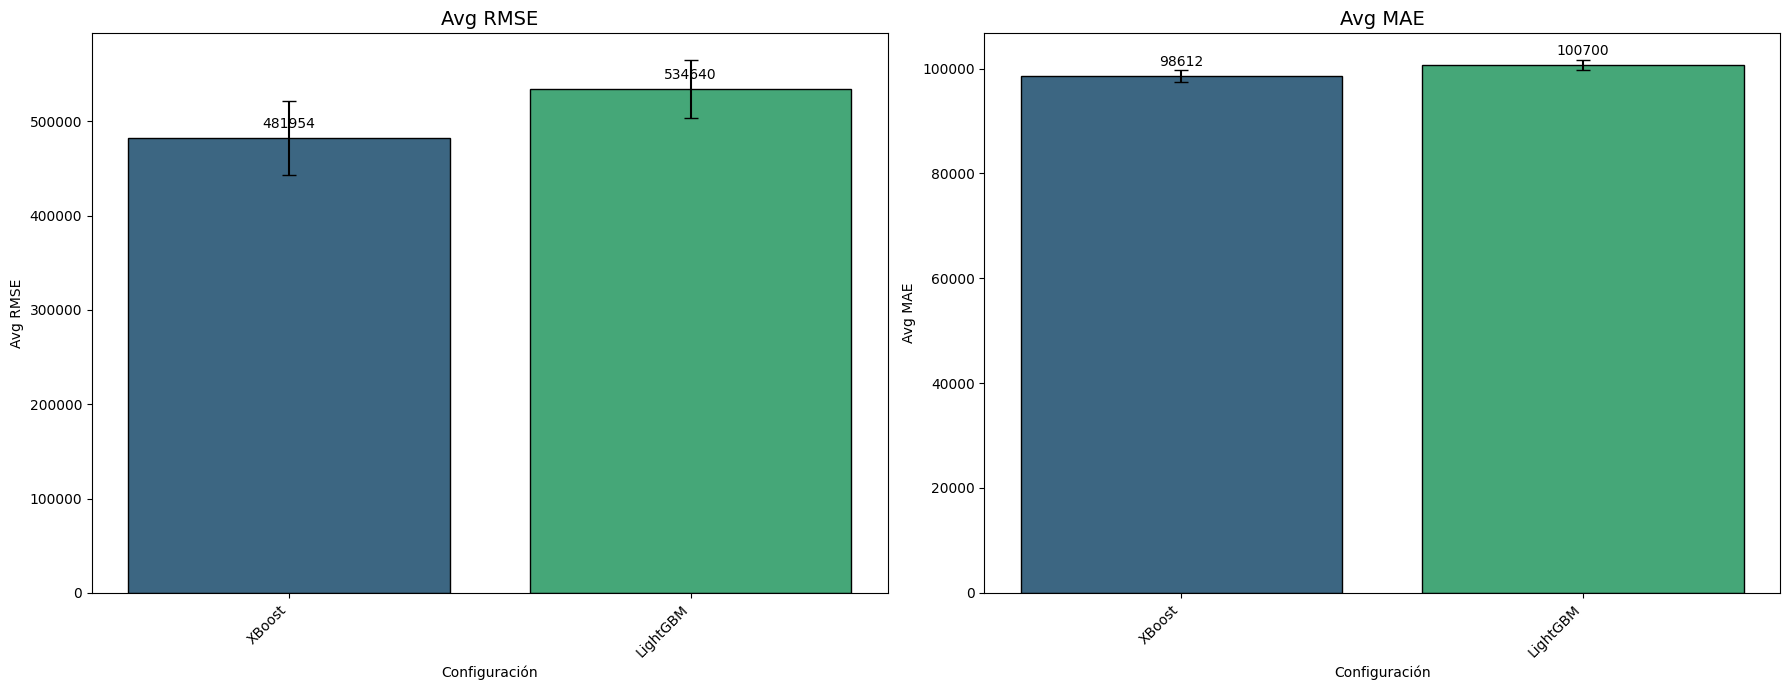

In [37]:
plot_cv_results(base_full_results, vertical_layout=False)

## 3.2 Grid Search - XGBoost

In [38]:
xgb_full_results = grid_search_cv(
    model_class=XGBRegressor,
    param_grid=xgb_random_search_params,
    X=X_full,
    y=y_full,
    feature_pipeline=feature_pipeline_normal,
    target_pipeline=target_pipeline_normal,
    n_splits=3,
    n_iter=300,
    verbose=True
)


🔍 RandomizedSearchCV: 300 combinaciones × 3 folds = 900 fits
   Modelo: XGBRegressor



Optimizando:   0%|          | 0/900 [00:00<?, ?it/s]


✅ Mejor MAE: 60,227
   Mejores params: {'regressor__model__colsample_bytree': np.float64(0.7815158165534557), 'regressor__model__gamma': np.float64(0.11802523167323198), 'regressor__model__learning_rate': np.float64(0.032049024199003795), 'regressor__model__max_depth': 14, 'regressor__model__min_child_weight': 1, 'regressor__model__n_estimators': 900, 'regressor__model__reg_lambda': np.float64(1.2435713629381495), 'regressor__model__subsample': np.float64(0.846857994641612)}
   Overfitting gap: 295.4% ❌ (overfitting!)


In [39]:
xgb_full_results.to_csv("../results/random_search/xgb_full.csv")
xgb_full_results_cut = get_best_not_overfitted(xgb_full_results)
xgb_full_results_cut.head()

,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
279,0.650502,0.329815,0.058486,14,8,500,3.753648,0.823192,83521.412644,399.323266,408406.686830,19461.659058,53542.998969,948.923383,227467.770145,5512.641688,55.989418
66,0.741341,0.291828,0.033320,14,4,600,3.490809,0.814439,72271.657208,227.449120,409084.630115,21587.041604,43772.347960,996.068048,212019.149591,6014.760576,65.108020
165,0.788613,0.271616,0.057774,14,17,900,3.882984,0.908369,91806.250860,468.562167,411589.087272,18872.587811,55334.171253,1311.155689,218288.667212,7081.723917,65.912399
88,0.661144,0.122979,0.058204,13,9,600,2.622557,0.764159,89453.925867,792.664486,412946.141233,19136.460172,59342.452065,1190.147037,236429.081491,7442.229583,50.741877
192,0.723172,0.352340,0.070556,12,8,500,0.941745,0.892332,86869.688513,590.937010,413163.017503,18716.176077,57370.535290,1321.866935,232578.978700,7203.395759,51.418647


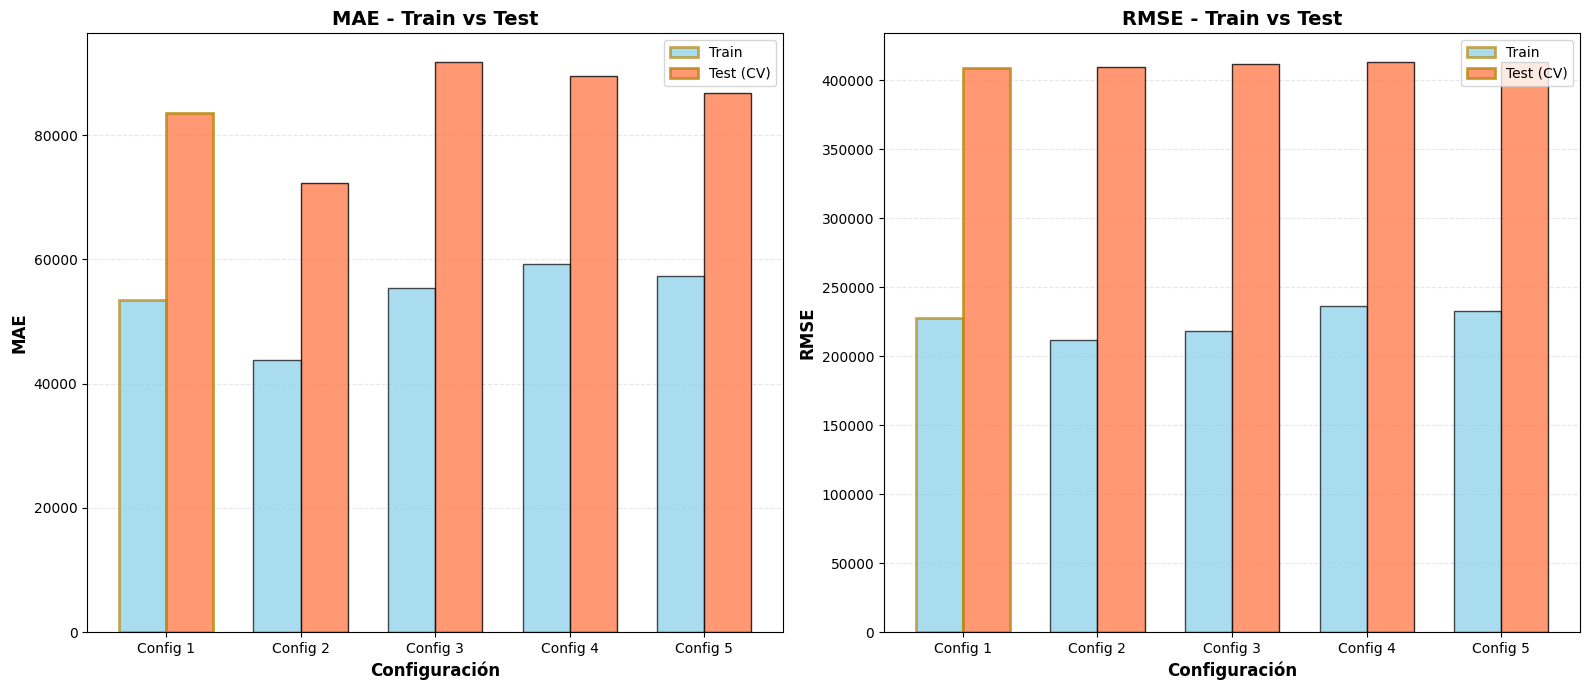


📋 Parámetros de cada configuración:
          colsample_bytree     gamma  learning_rate  max_depth  min_child_weight  n_estimators  reg_lambda  subsample      mae_mean  train_mae_mean  overfit_gap_%
Config 1          0.650502  0.329815       0.058486         14                 8           500    3.753648   0.823192  83521.412644    53542.998969      55.989418
Config 2          0.741341  0.291828       0.033320         14                 4           600    3.490809   0.814439  72271.657208    43772.347960      65.108020
Config 3          0.788613  0.271616       0.057774         14                17           900    3.882984   0.908369  91806.250860    55334.171253      65.912399
Config 4          0.661144  0.122979       0.058204         13                 9           600    2.622557   0.764159  89453.925867    59342.452065      50.741877
Config 5          0.723172  0.352340       0.070556         12                 8           500    0.941745   0.892332  86869.688513    57370.535290 

In [40]:
plot_grid_search_results(xgb_full_results_cut, top_n=5, overfitting_cutoff=OVERFITTING_CUTOFF)

## 3.3 Grid Search - LightGBM

In [41]:
lgbm_full_results = grid_search_cv(
    model_class=LGBMRegressor,
    param_grid=lgbm_param_grid,
    X=X_full,
    y=y_full,
    feature_pipeline=feature_pipeline_normal,
    target_pipeline=target_pipeline_normal,
    n_splits=3,
    verbose=True,
    n_iter=300,
)


🔍 RandomizedSearchCV: 300 combinaciones × 3 folds = 900 fits
   Modelo: LGBMRegressor



Optimizando:   0%|          | 0/900 [00:00<?, ?it/s]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2356
[LightGBM] [Info] Number of data points in the train set: 270722, number of used features: 39
[LightGBM] [Info] Start training from score 82152.448058

✅ Mejor MAE: 85,822
   Mejores params: {'regressor__model__colsample_bytree': np.float64(0.656009639021327), 'regressor__model__learning_rate': np.float64(0.09027614925947866), 'regressor__model__min_child_samples': 10, 'regressor__model__min_child_weight': np.float64(9.009306033156365), 'regressor__model__n_estimators': 1200, 'regressor__model__num_leaves': 44, 'regressor__model__reg_alpha': np.float64(0.9804885636919647), 'regressor__model__reg_lambda': np.float64(3.0539003553788415), 'regressor__mode

In [42]:
lgbm_full_results.to_csv("../results/random_search/lgbm_full.csv")
lgbm_full_results_cut = get_best_not_overfitted(lgbm_full_results)
lgbm_full_results_cut.head()

,colsample_bytree,learning_rate,min_child_samples,min_child_weight,n_estimators,num_leaves,reg_alpha,reg_lambda,subsample,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
206,0.893446,0.233098,11,2.676075,1200,47,1.299066,3.801449,0.654844,97190.997643,1313.183465,424725.703195,19862.766662,64128.298698,1475.487755,223450.940161,5180.363817,51.557112
271,0.656010,0.090276,10,9.009306,1200,44,0.980489,3.053900,0.712273,85821.588239,1105.235947,429655.154186,17995.118029,67677.735264,1289.745971,304554.453446,8591.483354,26.809191
210,0.863477,0.283421,11,8.752062,1200,42,4.204358,0.192132,0.960705,105793.171630,1531.864027,430133.300516,15692.021366,67094.330056,1400.766280,216105.142532,5755.260853,57.678259
157,0.691382,0.298937,12,1.630530,800,44,1.102806,2.091999,0.681431,105564.297085,455.302479,430140.447946,20635.147947,75636.416203,734.266801,255014.019174,7989.164933,39.568084
81,0.781707,0.169095,19,19.799205,1200,49,4.049372,1.273203,0.872601,106326.988805,295.079975,430150.247257,19976.174878,79739.261792,1146.184446,280980.363444,6612.773207,33.343332


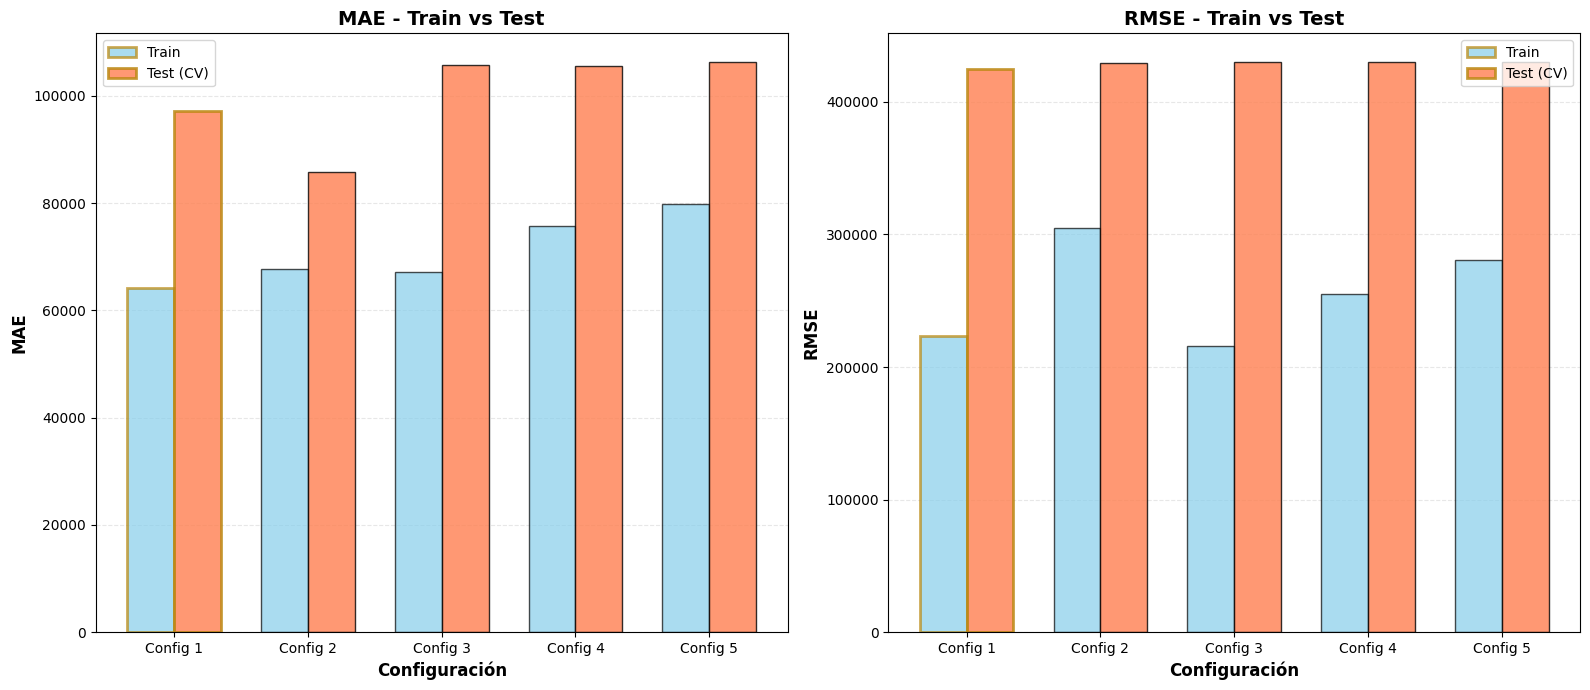


📋 Parámetros de cada configuración:
          colsample_bytree  learning_rate  min_child_samples  min_child_weight  n_estimators  num_leaves  reg_alpha  reg_lambda  subsample       mae_mean  train_mae_mean  overfit_gap_%
Config 1          0.893446       0.233098                 11          2.676075          1200          47   1.299066    3.801449   0.654844   97190.997643    64128.298698      51.557112
Config 2          0.656010       0.090276                 10          9.009306          1200          44   0.980489    3.053900   0.712273   85821.588239    67677.735264      26.809191
Config 3          0.863477       0.283421                 11          8.752062          1200          42   4.204358    0.192132   0.960705  105793.171630    67094.330056      57.678259
Config 4          0.691382       0.298937                 12          1.630530           800          44   1.102806    2.091999   0.681431  105564.297085    75636.416203      39.568084
Config 5          0.781707       0.169

In [43]:
plot_grid_search_results(lgbm_full_results_cut, top_n=5, overfitting_cutoff=OVERFITTING_CUTOFF)